# Scoring-First Analysis

**Question:** Does scoring first have any association with winning?

#

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns
from statsbombpy import sb
import numpy as np

## 1. Data Loading

In [2]:
competitions = sb.competitions()

C:\Users\admin\Documents\Projects\analytics-portfolio\fifa\.venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [3]:
competitions[(competitions['competition_name'] == 'FIFA World Cup') & (competitions['season_name'] == '2022')]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
30,43,106,International,FIFA World Cup,male,False,True,2022,2026-05-04T01:48:57.914346,2026-05-04T01:53:40.309717,2026-05-04T01:53:40.309717,2026-05-04T01:48:57.914346


In [4]:
matches = sb.matches(competition_id =43,season_id = 106)

C:\Users\admin\Documents\Projects\analytics-portfolio\fifa\.venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [5]:
matches

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3857276,2022-12-01,15:00:00.000,1,2,available,available,2026-05-04T01:46:04.664252,2026-05-04T01:50:33.318123,3,...,England,1000518,Walid Regragui,NaN,1975-09-23,154,Morocco,1.1.0,2,2
1,3857271,2022-11-21,13:00:00.000,6,2,available,available,2026-05-04T01:40:47.671394,2026-05-04T01:43:30.216315,1,...,England,645,Carlos Manuel Brito Leal Queiróz,Carlos Queiroz,1953-03-01,183,Portugal,1.1.0,2,2
2,3857296,2022-12-01,15:00:00.000,0,0,available,available,2026-05-04T01:44:02.255386,2026-05-04T01:50:06.343225,3,...,Croatia,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,1.1.0,2,2
3,3857274,2022-11-25,16:00:00.000,1,1,available,available,2026-05-04T01:43:00.444702,2026-05-04T01:50:07.646458,2,...,Netherlands,2881,Gustavo Julio Alfaro,Gustavo Alfaro,1962-08-14,11,Argentina,1.1.0,2,2
4,3857255,2022-12-01,19:00:00.000,2,1,available,available,2026-05-04T01:42:55.630428,2026-05-04T01:49:36.594944,3,...,Japan,793,Luis Enrique Martínez García,Luis Enrique,1970-05-08,214,Spain,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,3857291,2022-11-23,16:00:00.000,7,0,available,available,2026-05-03T16:08:38.580488,2026-05-03T16:12:13.412295,1,...,Spain,3094,Luis Fernando Suárez Guzman,Luis Fernando Suárez,1959-12-23,49,Colombia,1.1.0,2,2
60,3857281,2022-11-27,16:00:00.000,4,1,available,available,2026-05-04T01:47:00.853566,2026-05-04T01:51:52.104873,2,...,Croatia,4435,John Herdman,NaN,1975-07-19,68,England,1.1.0,2,2
61,3857280,2022-12-02,19:00:00.000,1,0,available,available,2026-05-03T15:41:58.839286,2026-05-03T15:44:07.018244,3,...,Cameroon,547,Adenor Leonardo Bacchi,Tite,1961-05-25,31,Brazil,1.1.0,2,2
62,3857279,2022-11-22,19:00:00.000,4,1,available,available,2026-05-04T01:44:53.405576,2026-05-04T01:50:33.615237,1,...,France,5696,Graham James Arnold,NaN,1963-08-03,14,Australia,1.1.0,2,2


In [6]:
matches.columns.tolist()

['match_id',
 'match_date',
 'kick_off',
 'home_score',
 'away_score',
 'match_status',
 'match_status_360',
 'last_updated',
 'last_updated_360',
 'match_week',
 'competition_id',
 'competition_country_name',
 'competition_name',
 'competition',
 'season_id',
 'season',
 'home_team_id',
 'home_team',
 'home_team_gender',
 'home_team_group',
 'home_team_country_id',
 'home_team_country_name',
 'away_team_id',
 'away_team',
 'away_team_gender',
 'away_team_group',
 'away_team_country_id',
 'away_team_country_name',
 'competition_stage_id',
 'competition_stage',
 'stadium_id',
 'stadium',
 'stadium_country_id',
 'stadium_country_name',
 'referee_id',
 'referee',
 'referee_country_id',
 'referee_country_name',
 'home_managers',
 'away_managers',
 'home_manager_id',
 'home_manager_name',
 'home_manager_nickname',
 'home_manager_dob',
 'home_manager_country_id',
 'home_manager_country_name',
 'away_manager_id',
 'away_manager_name',
 'away_manager_nickname',
 'away_manager_dob',
 'away_mana

In [7]:
matches_clean = matches[['match_id','home_team','away_team','home_score','away_score']]
matches_clean

,match_id,home_team,away_team,home_score,away_score
0,3857276,Canada,Morocco,1,2
1,3857271,England,Iran,6,2
2,3857296,Croatia,Belgium,0,0
3,3857274,Netherlands,Ecuador,1,1
4,3857255,Japan,Spain,2,1
...,...,...,...,...,...
59,3857291,Spain,Costa Rica,7,0
60,3857281,Croatia,Canada,4,1
61,3857280,Cameroon,Brazil,1,0
62,3857279,France,Australia,4,1


In [8]:
check_events = sb.events(match_id = 3857276)
check_events.head(10)

C:\Users\admin\Documents\Projects\analytics-portfolio\fifa\.venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4411, 'lineup': [{'player': {'id...",Canada,1833,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Morocco,788,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Morocco,788,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Canada,1833,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Morocco,788,00:00:00.000,Half Start,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Canada,1833,00:00:00.000,Half Start,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Morocco,788,00:00:00.460,Pass,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Morocco,788,00:00:02.415,Pass,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Morocco,788,00:00:05.143,Pass,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Morocco,788,00:00:08.720,Pass,NaN


In [9]:
event_list = []
for match_id in matches_clean['match_id']:
    match_events = sb.events(match_id=match_id)
    event_list.append(match_events)
    

C:\Users\admin\Documents\Projects\analytics-portfolio\fifa\.venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [10]:
event_list

[     50_50 ball_receipt_outcome ball_recovery_recovery_failure  \
 0      NaN                  NaN                            NaN   
 1      NaN                  NaN                            NaN   
 2      NaN                  NaN                            NaN   
 3      NaN                  NaN                            NaN   
 4      NaN                  NaN                            NaN   
 ...    ...                  ...                            ...   
 3383   NaN                  NaN                            NaN   
 3384   NaN                  NaN                            NaN   
 3385   NaN                  NaN                            NaN   
 3386   NaN                  NaN                            NaN   
 3387   NaN                  NaN                            NaN   
 
      block_deflection carry_end_location clearance_aerial_won  \
 0                 NaN                NaN                  NaN   
 1                 NaN                NaN                  NaN

In [11]:
all_events_df = pd.concat(event_list,ignore_index = True)

## 2. Data Preparation

In [12]:
all_events_df.columns.tolist()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_miscommunication

In [13]:
all_events_df[all_events_df['shot_outcome'] =='Goal']

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,shot_redirect,goalkeeper_punched_out,bad_behaviour_card,block_save_block,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,goalkeeper_lost_in_play
3037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
all_goals = all_events_df[(all_events_df['shot_outcome'] =='Goal') | (all_events_df['type'] =='Own Goal For')]

In [15]:
all_goals.shape

(198, 114)

In [16]:
all_goals['type'].value_counts()

type
Shot            195
Own Goal For      3
Name: count, dtype: int64

In [17]:
all_goals['period'].value_counts()

period
2    101
1     67
5     26
4      3
3      1
Name: count, dtype: int64

In [18]:
all_goals = all_goals[all_goals['period'].between(1,4)]

In [19]:
all_goals.columns.tolist()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_miscommunication

In [20]:
all_goals

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,shot_redirect,goalkeeper_punched_out,bad_behaviour_card,block_save_block,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,goalkeeper_lost_in_play
3037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
all_goals[all_goals['match_id'] ==3869685][['match_id','minute','second','period','team','type']]

,match_id,minute,second,period,team,type
103561,3869685,22,24,1,Argentina,Shot
103563,3869685,35,22,1,Argentina,Shot
103570,3869685,79,24,2,France,Shot
103571,3869685,80,59,2,France,Shot
103583,3869685,107,58,4,Argentina,Shot
103585,3869685,117,5,4,France,Shot


In [22]:
goals_sorted = all_goals.sort_values(['minute','second'], ascending = [True,True])

In [23]:
first_goals = goals_sorted.groupby('match_id').first()

In [24]:
first_goals.columns.tolist()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_miscommunication',
 'pass_out

In [25]:
first_goals.index.name

'match_id'

In [26]:
first_goals = first_goals.reset_index()

In [27]:
first_goals

,match_id,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,...,shot_redirect,goalkeeper_punched_out,bad_behaviour_card,block_save_block,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,goalkeeper_lost_in_play
0,3857255,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
1,3857256,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
2,3857257,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
3,3857258,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
4,3857259,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
5,3857260,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
6,3857261,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
7,3857262,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
8,3857263,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None
9,3857264,None,NaN,None,None,None,None,NaN,None,None,...,None,None,NaN,None,None,None,None,None,None,None


In [28]:
match_analysis = first_goals.merge(matches_clean, on ='match_id')

In [29]:
match_analysis

,match_id,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,...,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,goalkeeper_lost_in_play,home_team,away_team,home_score,away_score
0,3857255,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Japan,Spain,2,1
1,3857256,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Serbia,Switzerland,2,3
2,3857257,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Australia,Denmark,1,0
3,3857258,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Brazil,Serbia,2,0
4,3857259,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Cameroon,Serbia,3,3
5,3857260,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Saudi Arabia,Mexico,1,2
6,3857261,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Wales,England,0,3
7,3857262,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,South Korea,Portugal,2,1
8,3857263,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Spain,Germany,1,1
9,3857264,None,NaN,None,None,None,None,NaN,None,None,...,None,None,None,None,None,None,Poland,Argentina,0,2


In [30]:
match_analysis.columns.tolist()

['match_id',
 '50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_miscommunication

In [31]:
match_analysis = match_analysis[['match_id','team','home_team','away_team','home_score','away_score']]

In [32]:
match_analysis

,match_id,team,home_team,away_team,home_score,away_score
0,3857255,Spain,Japan,Spain,2,1
1,3857256,Switzerland,Serbia,Switzerland,2,3
2,3857257,Australia,Australia,Denmark,1,0
3,3857258,Brazil,Brazil,Serbia,2,0
4,3857259,Cameroon,Cameroon,Serbia,3,3
5,3857260,Mexico,Saudi Arabia,Mexico,1,2
6,3857261,England,Wales,England,0,3
7,3857262,Portugal,South Korea,Portugal,2,1
8,3857263,Spain,Spain,Germany,1,1
9,3857264,Argentina,Poland,Argentina,0,2


In [33]:
def check_winner(row):
    if row['team'] == row['home_team']:
        if row['home_score'] > row['away_score']:
            return 'Win'
        elif row['home_score'] < row['away_score']:
            return 'Loss'
        else:
            return 'Draw'
    elif row['team'] == row['away_team']:
        if row['away_score'] > row['home_score']:
            return 'Win'
        elif row['away_score'] < row['home_score']:
            return 'Loss'
        else:
            return 'Draw'
            
            

In [34]:
match_analysis['result'] = match_analysis.apply(check_winner,axis =1)

In [35]:
match_analysis

,match_id,team,home_team,away_team,home_score,away_score,result
0,3857255,Spain,Japan,Spain,2,1,Loss
1,3857256,Switzerland,Serbia,Switzerland,2,3,Win
2,3857257,Australia,Australia,Denmark,1,0,Win
3,3857258,Brazil,Brazil,Serbia,2,0,Win
4,3857259,Cameroon,Cameroon,Serbia,3,3,Draw
5,3857260,Mexico,Saudi Arabia,Mexico,1,2,Win
6,3857261,England,Wales,England,0,3,Win
7,3857262,Portugal,South Korea,Portugal,2,1,Loss
8,3857263,Spain,Spain,Germany,1,1,Draw
9,3857264,Argentina,Poland,Argentina,0,2,Win


In [36]:
match_analysis['result'].value_counts()

result
Win     43
Draw     8
Loss     6
Name: count, dtype: int64

In [37]:
result_test = st.binomtest(k =43,n=57,p=0.5,alternative ='greater')

In [38]:
result_test

BinomTestResult(k=43, n=57, alternative='greater', statistic=0.7543859649122807, pvalue=7.694451122217115e-05)

## 3. Results and Interpretation. 

We tested whether scoring first is associated with winning using data from 57 matches in the 2022 FIFA World Cup where at least one goal was scored in open play.

Out of the 57 matches, the team that scored first went on to win 43 times, which is a win rate of 75.4%.

To check whether this could have happened just by chance, we calculated a p-value. The p-value tells us how likely it is to observe a result like this if scoring first had no relationship with winning. In our case, the p-value was 0.00007, which is much smaller than our significance level (alpha) of 0.05.

Because the p-value is so low, we reject the null hypothesis. This suggests that there is a statistically significant association between scoring first and winning, and it is very unlikely that this result happened by chance alone.

However, it's important to remember that this does not mean scoring first causes a team to win. Other factors, such as team quality, match momentum, or home support, may also influence both who scores first and who wins the match.

## 4. Visualization


C:\Users\admin\AppData\Local\Temp\ipykernel_33528\3417841261.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = match_analysis, x= 'result', order=['Win','Draw','Loss'],palette=['#2ecc71','#bdc3c7','#bdc3c7'])


Text(0.5, 1.0, 'Score First, Win 75% of the Time — 2022 World Cup')

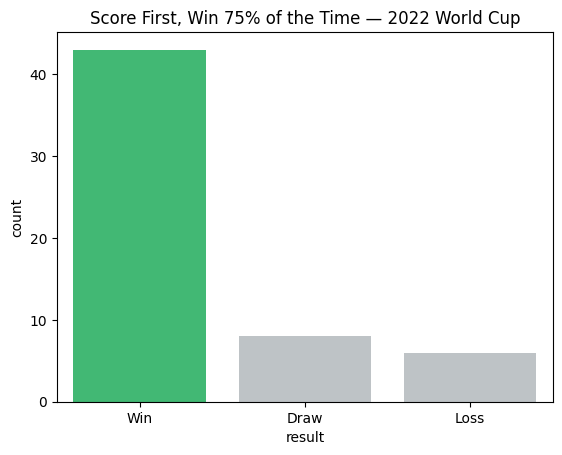

In [39]:
sns.countplot(data = match_analysis, x= 'result', order=['Win','Draw','Loss'],palette=['#2ecc71','#bdc3c7','#bdc3c7'])
plt.title('Score First, Win 75% of the Time — 2022 World Cup')

In [40]:
matches.columns.tolist()

['match_id',
 'match_date',
 'kick_off',
 'home_score',
 'away_score',
 'match_status',
 'match_status_360',
 'last_updated',
 'last_updated_360',
 'match_week',
 'competition_id',
 'competition_country_name',
 'competition_name',
 'competition',
 'season_id',
 'season',
 'home_team_id',
 'home_team',
 'home_team_gender',
 'home_team_group',
 'home_team_country_id',
 'home_team_country_name',
 'away_team_id',
 'away_team',
 'away_team_gender',
 'away_team_group',
 'away_team_country_id',
 'away_team_country_name',
 'competition_stage_id',
 'competition_stage',
 'stadium_id',
 'stadium',
 'stadium_country_id',
 'stadium_country_name',
 'referee_id',
 'referee',
 'referee_country_id',
 'referee_country_name',
 'home_managers',
 'away_managers',
 'home_manager_id',
 'home_manager_name',
 'home_manager_nickname',
 'home_manager_dob',
 'home_manager_country_id',
 'home_manager_country_name',
 'away_manager_id',
 'away_manager_name',
 'away_manager_nickname',
 'away_manager_dob',
 'away_mana

In [41]:
matches

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3857276,2022-12-01,15:00:00.000,1,2,available,available,2026-05-04T01:46:04.664252,2026-05-04T01:50:33.318123,3,...,England,1000518,Walid Regragui,NaN,1975-09-23,154,Morocco,1.1.0,2,2
1,3857271,2022-11-21,13:00:00.000,6,2,available,available,2026-05-04T01:40:47.671394,2026-05-04T01:43:30.216315,1,...,England,645,Carlos Manuel Brito Leal Queiróz,Carlos Queiroz,1953-03-01,183,Portugal,1.1.0,2,2
2,3857296,2022-12-01,15:00:00.000,0,0,available,available,2026-05-04T01:44:02.255386,2026-05-04T01:50:06.343225,3,...,Croatia,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,1.1.0,2,2
3,3857274,2022-11-25,16:00:00.000,1,1,available,available,2026-05-04T01:43:00.444702,2026-05-04T01:50:07.646458,2,...,Netherlands,2881,Gustavo Julio Alfaro,Gustavo Alfaro,1962-08-14,11,Argentina,1.1.0,2,2
4,3857255,2022-12-01,19:00:00.000,2,1,available,available,2026-05-04T01:42:55.630428,2026-05-04T01:49:36.594944,3,...,Japan,793,Luis Enrique Martínez García,Luis Enrique,1970-05-08,214,Spain,1.1.0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,3857291,2022-11-23,16:00:00.000,7,0,available,available,2026-05-03T16:08:38.580488,2026-05-03T16:12:13.412295,1,...,Spain,3094,Luis Fernando Suárez Guzman,Luis Fernando Suárez,1959-12-23,49,Colombia,1.1.0,2,2
60,3857281,2022-11-27,16:00:00.000,4,1,available,available,2026-05-04T01:47:00.853566,2026-05-04T01:51:52.104873,2,...,Croatia,4435,John Herdman,NaN,1975-07-19,68,England,1.1.0,2,2
61,3857280,2022-12-02,19:00:00.000,1,0,available,available,2026-05-03T15:41:58.839286,2026-05-03T15:44:07.018244,3,...,Cameroon,547,Adenor Leonardo Bacchi,Tite,1961-05-25,31,Brazil,1.1.0,2,2
62,3857279,2022-11-22,19:00:00.000,4,1,available,available,2026-05-04T01:44:53.405576,2026-05-04T01:50:33.615237,1,...,France,5696,Graham James Arnold,NaN,1963-08-03,14,Australia,1.1.0,2,2


In [42]:
matches.groupby('match_date')

In [43]:
    matches[['match_date','competition_stage']].drop_duplicates()

,match_date,competition_stage
0,2022-12-01,Group Stage
1,2022-11-21,Group Stage
3,2022-11-25,Group Stage
6,2022-11-29,Group Stage
7,2022-11-23,Group Stage
9,2022-11-30,Group Stage
11,2022-11-24,Group Stage
15,2022-11-26,Group Stage
19,2022-11-22,Group Stage
23,2022-11-28,Group Stage


In [44]:
stage_lookup = matches[['match_id','competition_stage']]

In [45]:
stage_lookup

,match_id,competition_stage
0,3857276,Group Stage
1,3857271,Group Stage
2,3857296,Group Stage
3,3857274,Group Stage
4,3857255,Group Stage
...,...,...
59,3857291,Group Stage
60,3857281,Group Stage
61,3857280,Group Stage
62,3857279,Group Stage


In [46]:
match_analysis = match_analysis.merge(stage_lookup,on = 'match_id')

In [47]:
match_analysis

,match_id,team,home_team,away_team,home_score,away_score,result,competition_stage
0,3857255,Spain,Japan,Spain,2,1,Loss,Group Stage
1,3857256,Switzerland,Serbia,Switzerland,2,3,Win,Group Stage
2,3857257,Australia,Australia,Denmark,1,0,Win,Group Stage
3,3857258,Brazil,Brazil,Serbia,2,0,Win,Group Stage
4,3857259,Cameroon,Cameroon,Serbia,3,3,Draw,Group Stage
5,3857260,Mexico,Saudi Arabia,Mexico,1,2,Win,Group Stage
6,3857261,England,Wales,England,0,3,Win,Group Stage
7,3857262,Portugal,South Korea,Portugal,2,1,Loss,Group Stage
8,3857263,Spain,Spain,Germany,1,1,Draw,Group Stage
9,3857264,Argentina,Poland,Argentina,0,2,Win,Group Stage


In [48]:
match_analysis['Stage_Bucket'] = np.where(match_analysis['competition_stage'] == "Group Stage","Group Stage","Knockouts")

In [49]:
match_analysis

,match_id,team,home_team,away_team,home_score,away_score,result,competition_stage,Stage_Bucket
0,3857255,Spain,Japan,Spain,2,1,Loss,Group Stage,Group Stage
1,3857256,Switzerland,Serbia,Switzerland,2,3,Win,Group Stage,Group Stage
2,3857257,Australia,Australia,Denmark,1,0,Win,Group Stage,Group Stage
3,3857258,Brazil,Brazil,Serbia,2,0,Win,Group Stage,Group Stage
4,3857259,Cameroon,Cameroon,Serbia,3,3,Draw,Group Stage,Group Stage
5,3857260,Mexico,Saudi Arabia,Mexico,1,2,Win,Group Stage,Group Stage
6,3857261,England,Wales,England,0,3,Win,Group Stage,Group Stage
7,3857262,Portugal,South Korea,Portugal,2,1,Loss,Group Stage,Group Stage
8,3857263,Spain,Spain,Germany,1,1,Draw,Group Stage,Group Stage
9,3857264,Argentina,Poland,Argentina,0,2,Win,Group Stage,Group Stage


In [50]:
match_analysis.groupby('Stage_Bucket')['result'].value_counts()


Stage_Bucket  result
Group Stage   Win       32
              Loss       6
              Draw       4
Knockouts     Win       11
              Draw       4
Name: count, dtype: int64

In [51]:
match_analysis.groupby('Stage_Bucket')['result'].value_counts(normalize=True)*100

Stage_Bucket  result
Group Stage   Win       76.190476
              Loss      14.285714
              Draw       9.523810
Knockouts     Win       73.333333
              Draw      26.666667
Name: proportion, dtype: float64

In [52]:
stage_analysis= match_analysis.groupby('Stage_Bucket')['result'].value_counts(normalize=True)*100

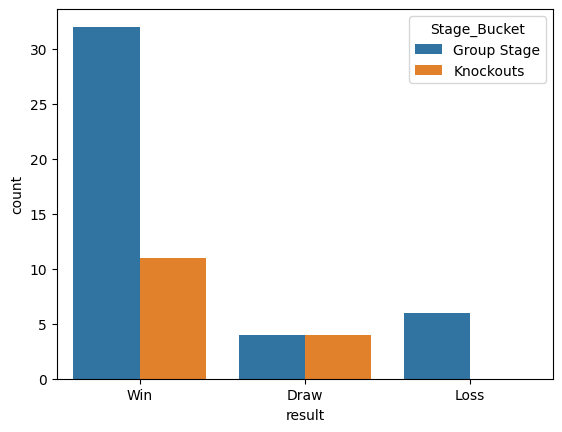

In [53]:
ax = sns.countplot(data=match_analysis, x='result', hue='Stage_Bucket', order=['Win','Draw','Loss'])

In [54]:
ax.containers

[<BarContainer object of 3 artists>, <BarContainer object of 2 artists>]

In [55]:
stage_analysis

Stage_Bucket  result
Group Stage   Win       76.190476
              Loss      14.285714
              Draw       9.523810
Knockouts     Win       73.333333
              Draw      26.666667
Name: proportion, dtype: float64

In [56]:
ax.bar_label(ax.containers[0], labels =['76.2%','9.5%','14.2%'])

[Text(0, 0, '76.2%'), Text(0, 0, '9.5%'), Text(0, 0, '14.2%')]

In [57]:
ax.bar_label(ax.containers[1], labels =['73.3%','26.6%'])

[Text(0, 0, '73.3%'), Text(0, 0, '26.6%')]

Text(0.5, 1.0, 'Scoring First Wins Over 70% of the Time — Group Stage and Knockouts')

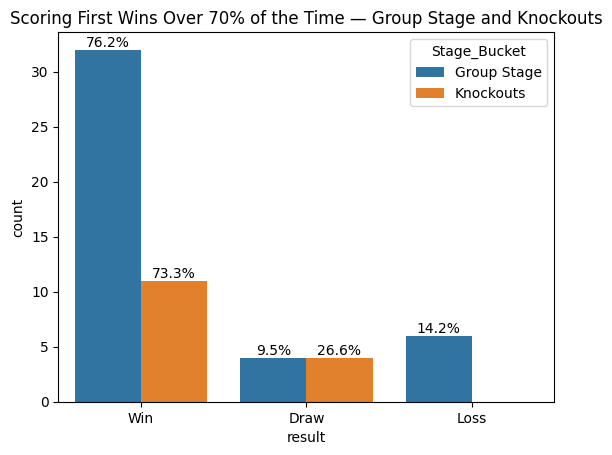

In [63]:
ax = sns.countplot(data=match_analysis, x='result', hue='Stage_Bucket', order=['Win','Draw','Loss'])
ax.bar_label(ax.containers[0], labels =['76.2%','9.5%','14.2%'])
ax.bar_label(ax.containers[1], labels =['73.3%','26.6%'])
plt.title('Scoring First Wins Over 70% of the Time — Group Stage and Knockouts')


In [69]:
all_goals.columns.tolist()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_miscommunication

In [67]:
goal_lookup = matches[['match_id','match_date']]

In [68]:
all_goals = all_goals.merge(goal_lookup, on ='match_id')

In [70]:
all_goals['match_date'] = pd.to_datetime(all_goals['match_date'])

In [71]:
all_goals

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,...,goalkeeper_punched_out,bad_behaviour_card,block_save_block,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_follows_dribble,half_start_late_video_start,goalkeeper_lost_in_play,match_date
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-01
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-01
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-01
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-21
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-22
168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11-22
169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-02
170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-02


In [79]:
all_goals.columns.tolist()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_other',
 'clearance_right_foot',
 'counterpress',
 'dribble_no_touch',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',
 'pass_length',
 'pass_miscommunication

In [73]:
all_goals.dtypes['match_date']

dtype('<M8[us]')

In [86]:
goals_per_day = all_goals.groupby('match_date')['id'].count()
goals_per_day.reset_index()

,match_date,id
0,2022-11-20,2
1,2022-11-21,12
2,2022-11-22,8
3,2022-11-23,11
4,2022-11-24,8
5,2022-11-25,8
6,2022-11-26,8
7,2022-11-27,10
8,2022-11-28,14
9,2022-11-29,9


In [88]:
sns.lineplot(data  = goals_per_day, x = 'match_date', y = 'id')
plt.title('Goals Scored Per Day : World Cup 2022')

TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.